In [2]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [3]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
)
from src.plotting import (
    make_animation,
    plot
)
from src.analysis.classifiers import classify_temporal_behavior
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
from skimage import measure
import xarray as xr

In [4]:
model = "gray_scott"
ds_id = "gs_stat"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR", dataset_file="_dataset_processed.nc")
df = ds.df
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]
# df = classify_temporal_behavior(df, 0.1, 50, 0)
# df = df[df.A > 1]

In [5]:
ind = np.load('/cluster/scratch/vogtva/models/bruss_final_early/model200/indices.npy')

In [8]:
df["set"] = 0
df.loc[df.idx.isin(ind[-300:-100]), "set"]= 1

In [22]:
# df["q"] = np.power(df.A,2) / np.power(np.sqrt(df.B) - 1,2)
# df_sub = df[(df.A < 1) & (df.ratio_b_a.between(2,3)) & (df.q < 40)]
# df_sub = df[(df.A > 0.055) & (df.ratio_b_a > 0.9) & (df.mean_dt > 0.2)]
# df_sub = df[((df.ratio_d > 9) | (df.ratio_b_a > 1.5))]# | ((df.ratio_d > 9) & (df.ratio_b_a < 1.5))]
fig = px.scatter_3d(
    df,
    x="A",
    y="ratio_b_a",
    z="rel_std_u", 
    hover_data={"idx": True},
    color_continuous_scale=px.colors.sequential.Bluered,
)
fig.update_traces(marker_size=2)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)
# x_vals = np.linspace(df_sub['A'].min(), df_sub['A'].max(), 400)
# y_vals = np.linspace(df_sub['ratio_b_a'].min(), df_sub['ratio_b_a'].max(), 400)
# X, Y = np.meshgrid(x_vals, y_vals)
# Z = X**2 / (np.sqrt(X*Y) - 1) **2 - 9

# contours = measure.find_contours(Z, level=0)
# for contour in contours:
#     # Convert contour pixel coords to data coords
#     contour_x = x_vals[contour[:, 1].astype(int)]
#     contour_y = y_vals[contour[:, 0].astype(int)]
#     contour_z = np.zeros_like(contour_x)

#     fig.add_trace(go.Scatter3d(
#         x=contour_x,
#         y=contour_y,
#         z=contour_z,
#         mode='lines',
#         line=dict(color='black', width=4),
#         name='Phase transition boundary'
#     ))

fig.show()

ValueError: Value of 'z' is not the name of a column in 'data_frame'. Expected one of ['A', 'B', 'Du', 'Dv', 'input_filename', 'n_snapshots', 'idx', 'ratio_b_a', 'ratio_d'] but received: rel_std_u

In [46]:
indices_by_param_set = []
for A in sorted(df.A.unique()):
    indices_by_param_set.append((A, df[df.A == A].idx))

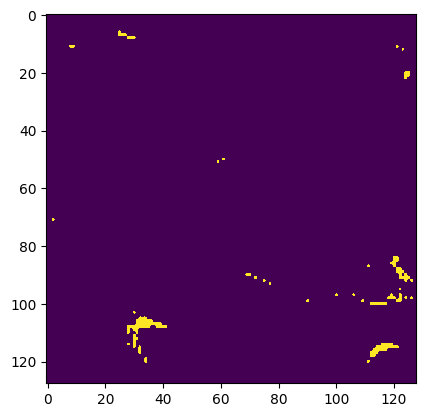

In [44]:
data = ds.dataset["data"]
plt.imshow(data[44,-1,0])
# make_animation(data[545], "0", ".", "new")

In [30]:
df.iloc[545]["A"]

0.025529

In [37]:
[indices_by_param_set[i][0] for i in range(10)]

[0.020271,
 0.038307,
 0.069943,
 0.030094,
 0.024723,
 0.071541,
 0.014345,
 0.024837,
 0.017687,
 0.025529]

In [38]:
545 in list(indices_by_param_set[0][9])

IndexError: tuple index out of range

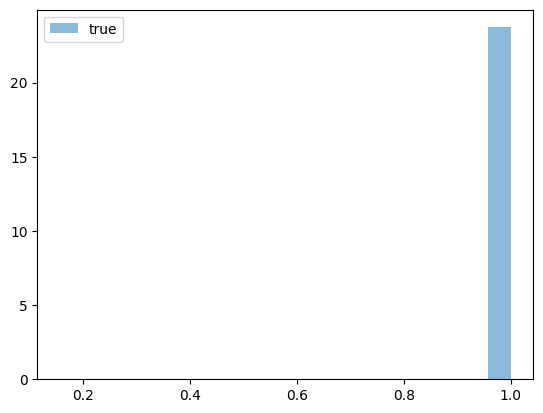

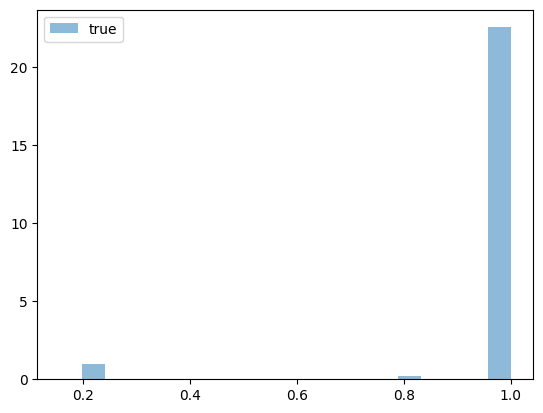

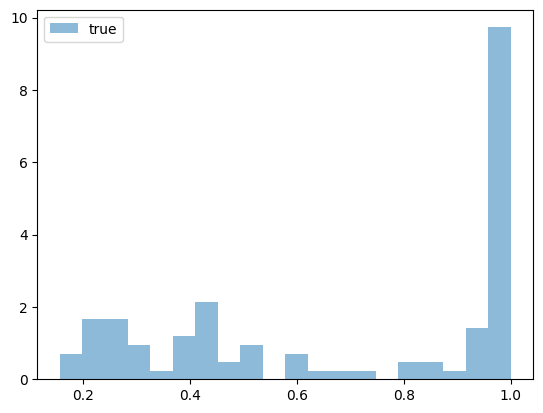

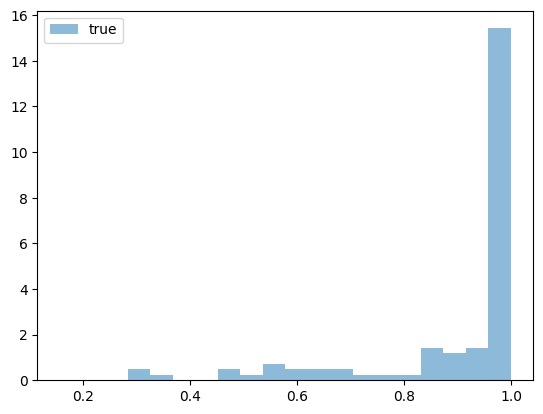

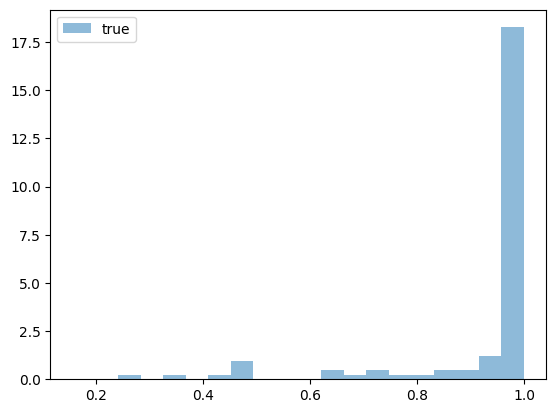

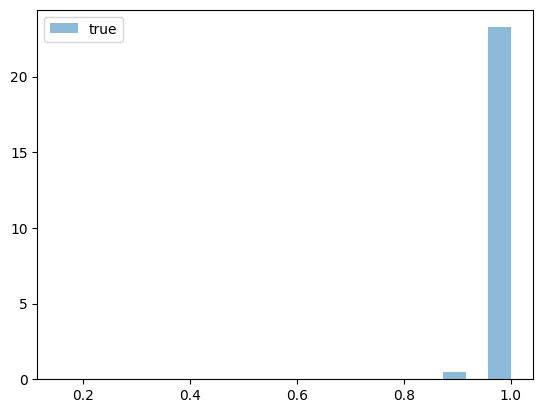

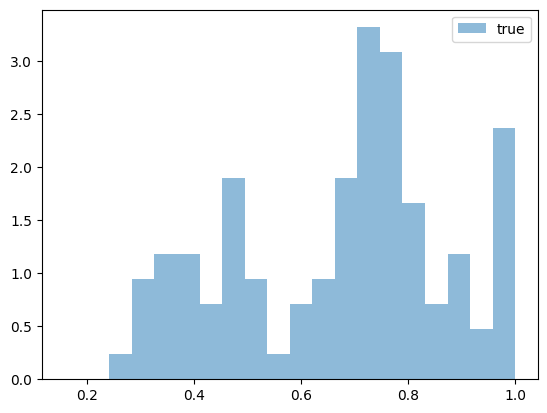

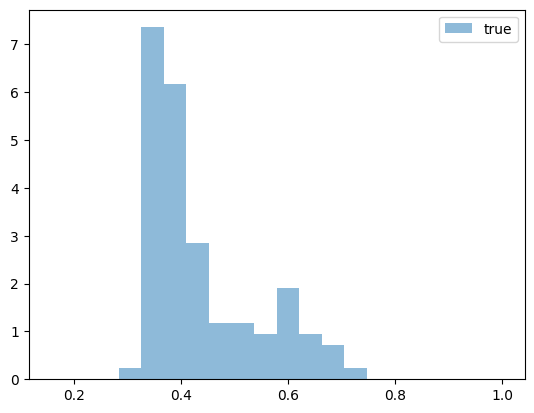

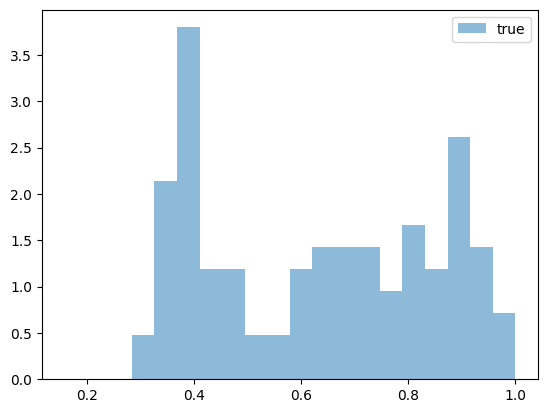

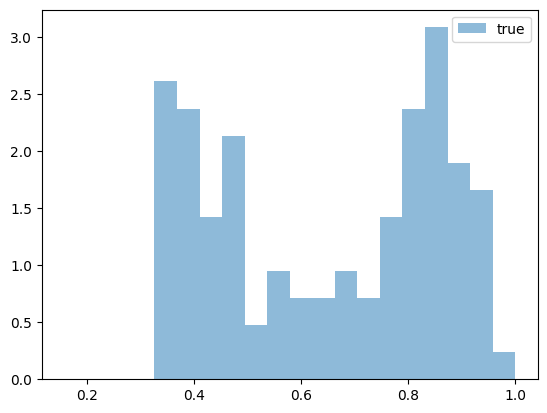

In [51]:
global_min = float('inf')
global_max = float('-inf')

data = ds.dataset["data"]
for i0 in range(10):
    indices = indices_by_param_set[i0][1]
    tp = data[indices, -1, 0, 32, 32]
    global_min = min(global_min, tp.min())
    global_max = max(global_max, tp.max())

# Define global bins
bins = np.histogram_bin_edges(np.linspace(global_min, global_max, 200), bins=20)


pixels = [(32, 32)]
for i0 in range(10):
    for x,y in pixels:
        # indices = global_indices[indices_by_param_set[i0][1]]
        indices = indices_by_param_set[i0][1]
        tp = data[indices, -1, 0, 32, 32]
        # pred_pixel_data = pred_data[indices, x, y]

        # combined = np.concatenate([true_pixel_data, pred_pixel_data])
        # bins = np.histogram_bin_edges(combined, bins=10)
        # h_true = normalize_hist(tp, bins)

        # div = jensenshannon(h_true, h_pred, base=2)  # Result ∈ [0, 1]
        # divergences[pattern].append(div)

        plt.hist(tp, bins=bins, alpha=0.5, label="true", density=True)
        # plt.hist(pred_pixel_data, bins=bins, alpha=0.5, label="pred", density=True)
        plt.legend()
        plt.show()
        plt.close('all')    
        # _[{x},{y}]
        # plt.savefig(f"out/hist_gs/traj_{i0}_p_{pattern}.png")
        # plt.close('all')    

[ 35  52 560 251]


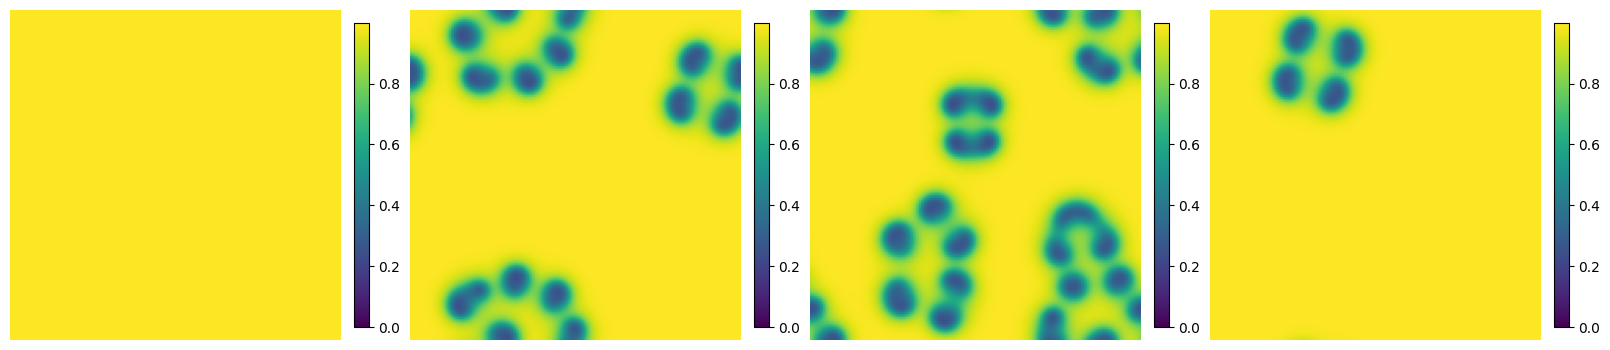

In [49]:
df_pc = df[df.A == df.A.unique()[7]] #[(df.ratio_b_a < 1.5) & (df.ratio_d > 9)]
# for pc in [2]:
    # df_pc = filter_df(df, pattern_class=pc)
    # if len(df_pc) < 3:
    #     continue
    # print(pc)
fig, ax = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
sub_indices = df_pc["idx"].sample(4).values
print(sub_indices)
for i, idx in enumerate(sub_indices):
    traj = ds.get_data(idx)
    ff = traj[-1,0] # :, 0::2]
    # plot(ff, ax=ax[i], title=f"Pattern Class {pc}, Trajectory {idx}")
    ax[i].imshow(ff, cmap="viridis", vmin=0)
    ax[i].axis('off')
    im = ax[i].imshow(ff, cmap="viridis", vmin=0)
    fig.colorbar(im, ax=ax[i], orientation='vertical', fraction=0.046, pad=0.04)
# plt.axis('off')
# plt.tight_layout()
plt.savefig("gs_sp_dots.png", dpi=200)

In [ ]:
traj.shape

(10, 6, 128, 128)

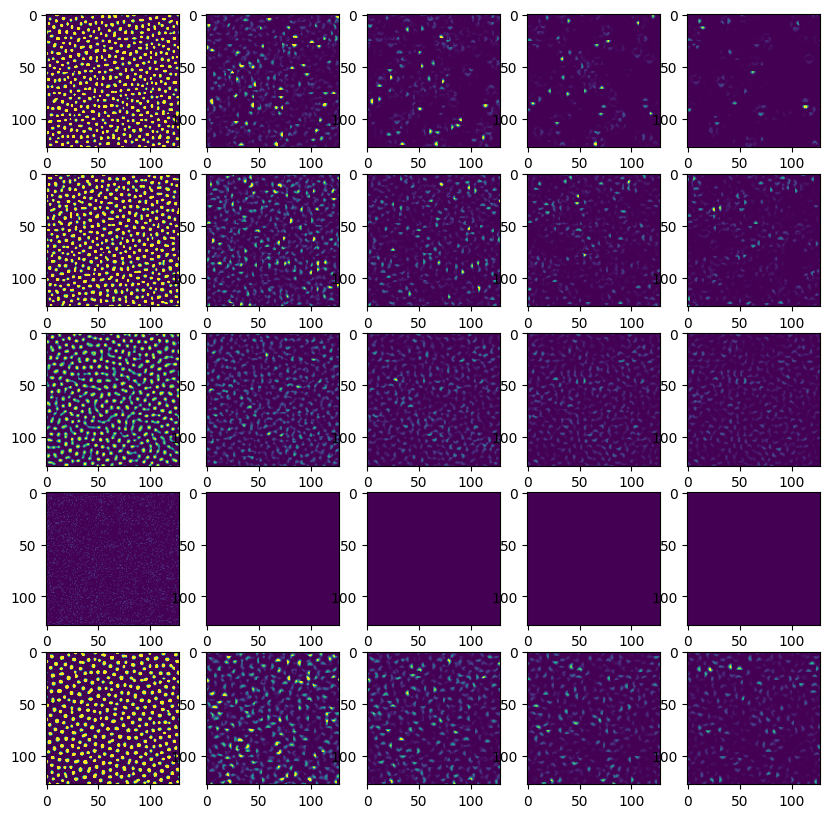

In [18]:
# df_sub = df[df.pattern_class == 2]
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
for i, (idx, row) in enumerate(df.sample(5).iterrows()):
        traj = ds.get_data(idx)
        for j in range(0, 5):
                ax[i, j].imshow((traj[j+1, 0] - traj[j, 0])/traj[j, 0], cmap="viridis", vmin=0, vmax=1)


In [14]:
d = ds.get_data(1015)

In [20]:
d[0]

<xarray.Variable (component: 2, x: 128, y: 128)> Size: 131kB
[32768 values with dtype=float32]

In [19]:
df.iloc[1015]

A                                                          0.785912
B                                                          4.823138
Du                                                         0.925933
Dv                                                         9.953681
input_filename    /cluster/scratch/vogtva/data/bruss/final_2/82d...
n_snapshots                                                     101
idx                                                            1015
mean_deviation                                             713.3486
std_deviation                                               0.05018
max_dx                                                    220.38385
mean_dx                                                     220.292
max_dt                                                      3.94466
mean_dt                                                    0.842087
dominant_power                                             0.043723
total_power                                     

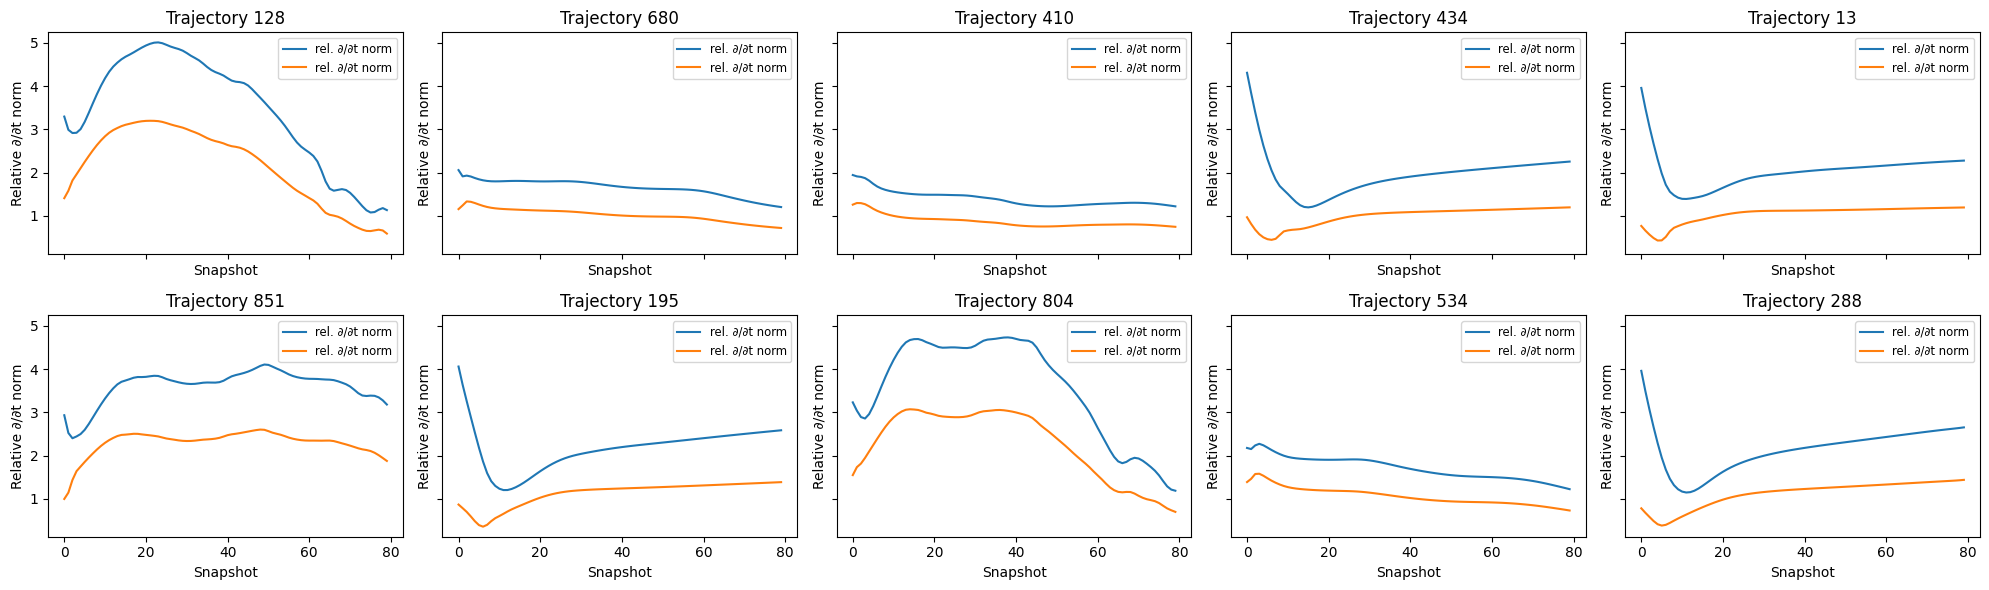

In [15]:
df_sub = df[df.mean_dt > 2].sample(10)
indices = df_sub.idx
d = ds.dataset["data"][indices.values]
# stacked = np.stack([d[:,:,:,0::2], d[:,:,:,1::2]], axis=2)
# stacked = stacked[:,:,:,1:-1,1:-1]
stacked = d

data = stacked

# Compute discrete time derivative
dt_data = np.diff(data, axis=1)  # shape: [B, n_snap-1, Nx, 2Ny]

dt_norm = np.linalg.norm(dt_data, axis=(3, 4))  # [B, n_snap-1]

n_traj = 10
n_cols = 5
n_rows = int(np.ceil(n_traj / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_traj):
    ax = axes[i]
    ax.plot(dt_norm[i][20:], label="rel. ∂/∂t norm")
    # ax.axvline(settling_times[i] - 1, color='r', linestyle='--', label="settling time")
    ax.set_title(f"Trajectory {indices.iloc[i]}")
    ax.set_xlabel("Snapshot")
    ax.set_ylabel("Relative ∂/∂t norm")
    # ax.set_yscale('log')
    ax.legend(fontsize="small")

# Hide unused axes
for j in range(n_traj, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [30]:
i = 295
make_animation(ds.get_data(i), i, ".", "new")

MovieWriter ffmpeg unavailable; using Pillow instead.


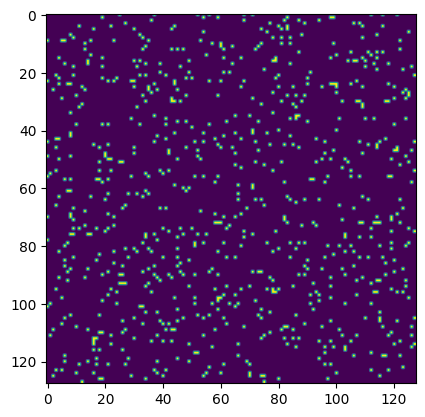

In [10]:
plt.imshow(ds.get_data(i)[0, 1])

In [6]:
df_sub = df[(df.A < 1) & (df.ratio_b_a.between(2,3))]

In [12]:
df['pattern_class'].unique()

array([0, 2, 1])

In [10]:
df.pattern_class.value_counts()

pattern_class
0    140
1    110
Name: count, dtype: int64

In [9]:
df_sub = df[df.pattern_class == 1]
for i, row in df_sub.sample(10).iterrows():
    d = ds.get_data(i)
    # print(row["A"], row["ratio_b_a"], flush=True)
    # plot(d, 0, np.max(d), 0, "new")
    print(d[0, 1].sum() / 128**2) 
    plt.show()

<xarray.Variable ()> Size: 8B
array(0.02478027)
<xarray.Variable ()> Size: 8B
array(0.00994873)
<xarray.Variable ()> Size: 8B
array(0.0244751)
<xarray.Variable ()> Size: 8B
array(0.0246582)
<xarray.Variable ()> Size: 8B
array(0.00994873)
<xarray.Variable ()> Size: 8B
array(0.0246582)
<xarray.Variable ()> Size: 8B
array(0.00994873)
<xarray.Variable ()> Size: 8B
array(0.02459717)
<xarray.Variable ()> Size: 8B
array(0.02441406)
<xarray.Variable ()> Size: 8B
array(0.0098877)


In [ ]:
indices = [102, 1104, 1814, 2547, 3365, 3466, 6760, 7333, 7698, 9312, 9520, 10686]
df_sel = df.iloc[indices]

<Axes: xlabel='ratio_b_a', ylabel='A'>

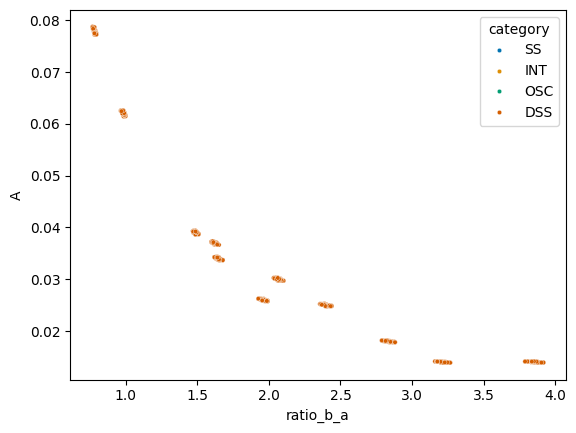

In [8]:
colorblind_palette = sns.color_palette("colorblind")

# Define a fixed hue mapping
categories = ["SS", "INT", "OSC", "DSS"]
hue_mapping = {cat: colorblind_palette[i] for i, cat in enumerate(categories)}

sns.scatterplot(df, x="ratio_b_a", y="A", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)
